# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


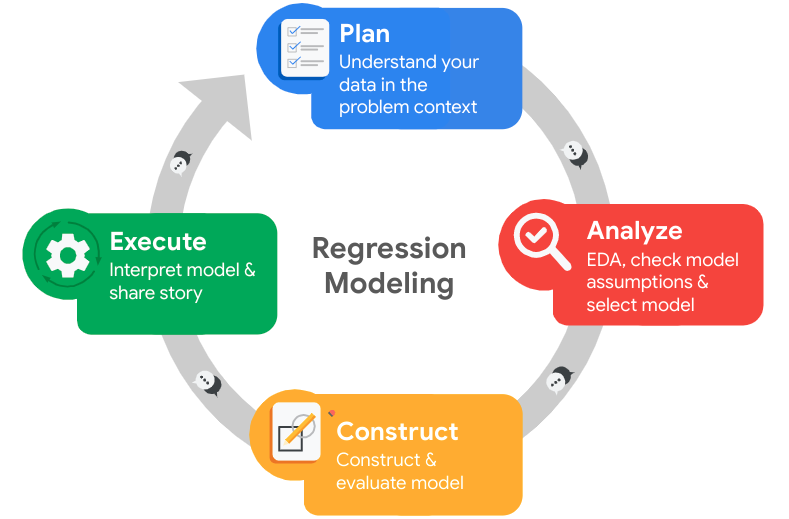

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [4]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
# Import packages
### YOUR CODE HERE ### 
#!pip install xgboost shap scikit-learn pandas matplotlib seaborn numba
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [7]:
#Loading the file
df0 = pd.read_csv("HR_capstone_dataset.csv")

df0.head()



,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [8]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.shape

(14999, 10)

### Gather descriptive statistics about the data

In [9]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [10]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [11]:
# Renaming columns
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})
# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [12]:
# Check for missing values
### YOUR CODE HERE ###
df0.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [13]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

np.int64(3008)

In [14]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [15]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [16]:
df1.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Check outliers

Check for outliers in the data.

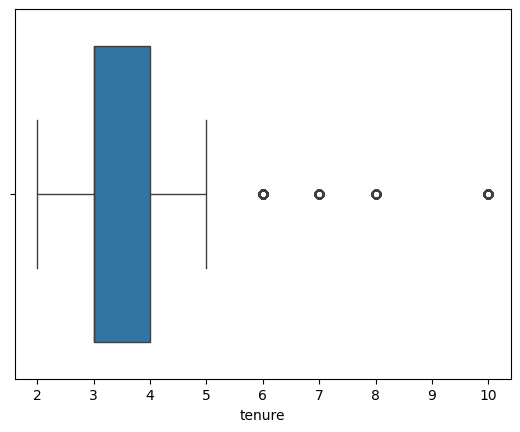

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualise a specific column
sns.boxplot(x=df1['tenure'])
plt.show()


In [18]:
# Determine the number of rows containing outliers
percentile25 = df1['tenure'].quantile(0.25)

percentile75 = df1['tenure'].quantile(0.75)

iqr = percentile75 - percentile25

upper_lim = percentile75 + 1.5 * iqr
lower_lim = percentile25 -1.5 * iqr

print('Upper limit = ', upper_lim)
print('Lower limit = ', lower_lim)

outliers = df1[(df1['tenure'] > upper_lim) | (df1['tenure'] < lower_lim)]

outliers

Upper limit =  5.5
Lower limit =  1.5


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
1,0.80,0.86,5,262,6,0,1,0,sales,medium
17,0.78,0.99,4,255,6,0,1,0,sales,low
34,0.84,0.87,4,246,6,0,1,0,hr,low
47,0.57,0.70,3,273,6,0,1,0,support,low
67,0.90,0.98,4,264,6,0,1,0,product_mng,medium
...,...,...,...,...,...,...,...,...,...,...
11994,0.22,0.94,3,193,10,0,0,1,management,high
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [19]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
df1['left'].value_counts()
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
df1['left'].value_counts(normalize = True)

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

### Data visualizations and EDA

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

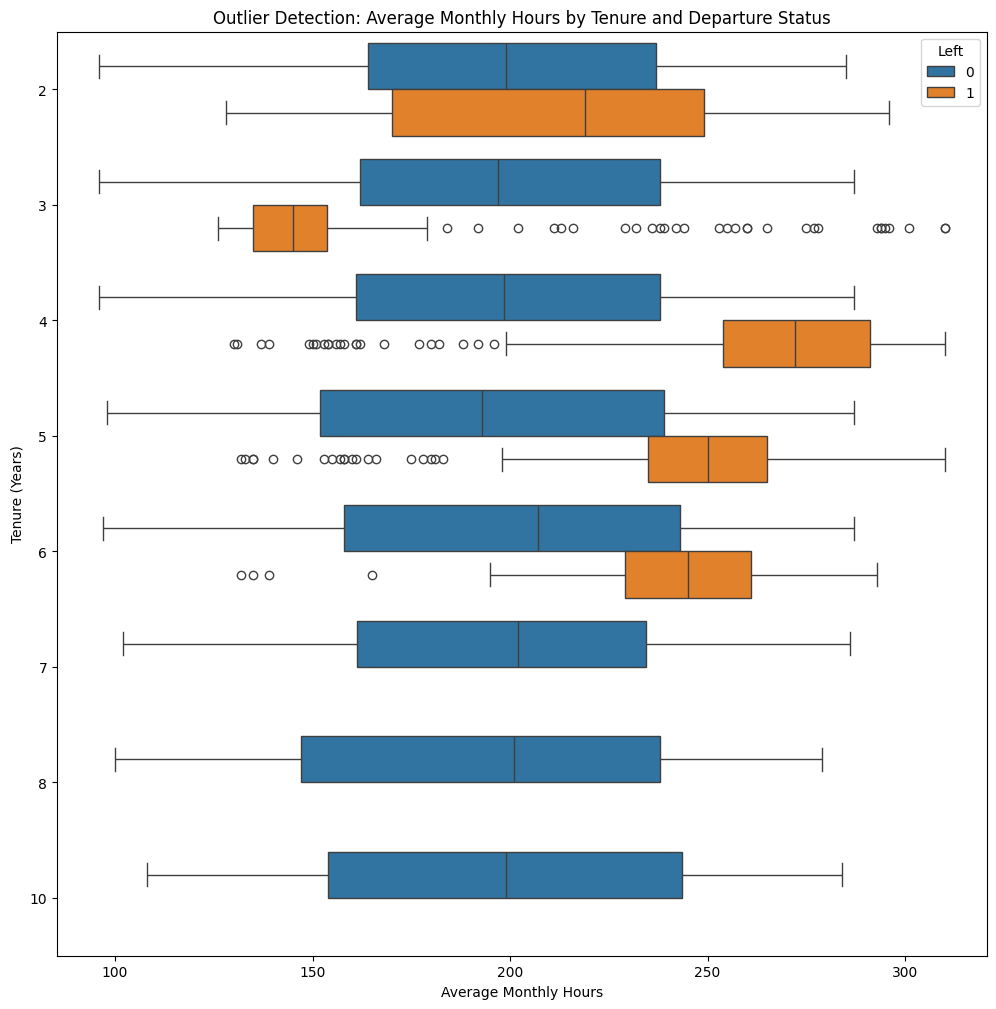

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

# Creating the boxplot
sns.boxplot(data=df1, x='average_monthly_hours', y='tenure', hue='left', orient='h')

plt.title('Outlier Detection: Average Monthly Hours by Tenure and Departure Status')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Tenure (Years)')
plt.legend(title='Left')

plt.show()


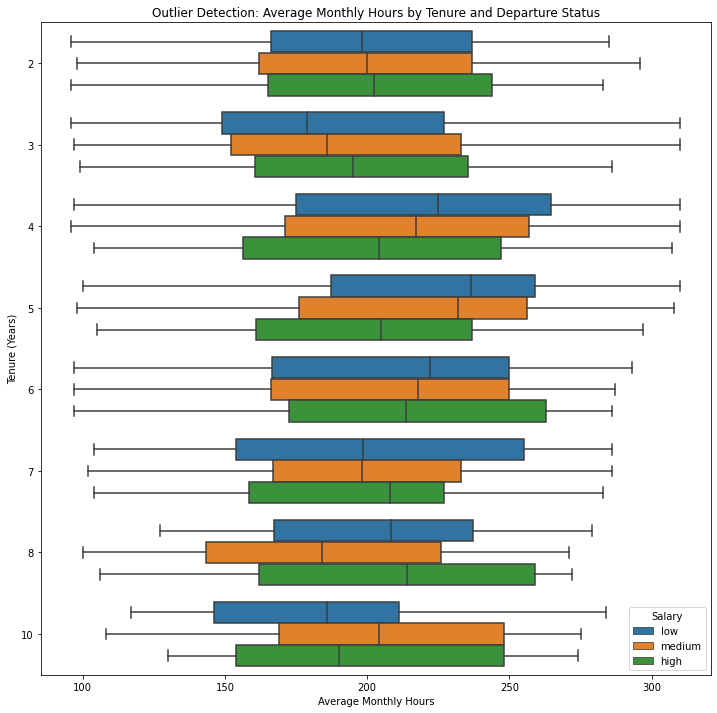

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

# Creating the boxplot
sns.boxplot(data=df1, x='average_monthly_hours', y='tenure', hue='salary', orient='h')

plt.title('Outlier Detection: Average Monthly Hours by Tenure and Departure Status')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Tenure (Years)')
plt.legend(title='Salary')

plt.show()


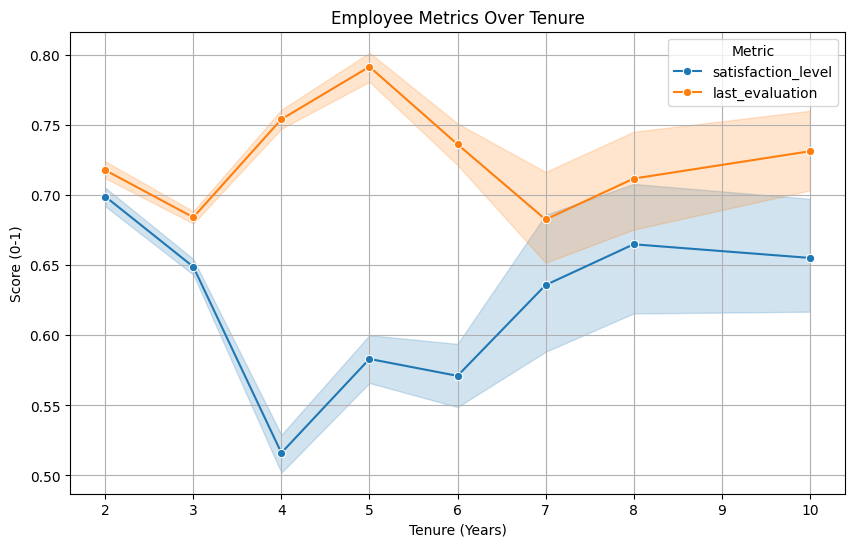

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reshape the data so satisfaction and evaluation are in one column
df_melted = df1.melt(id_vars='tenure', 
                    value_vars=['satisfaction_level', 'last_evaluation'],
                    var_name='Metric', 
                    value_name='Score')

# 2. Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='tenure', y='Score', hue='Metric', marker='o')

# 3. Add titles and labels
plt.title('Employee Metrics Over Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Score (0-1)')
plt.grid(True)
plt.show()


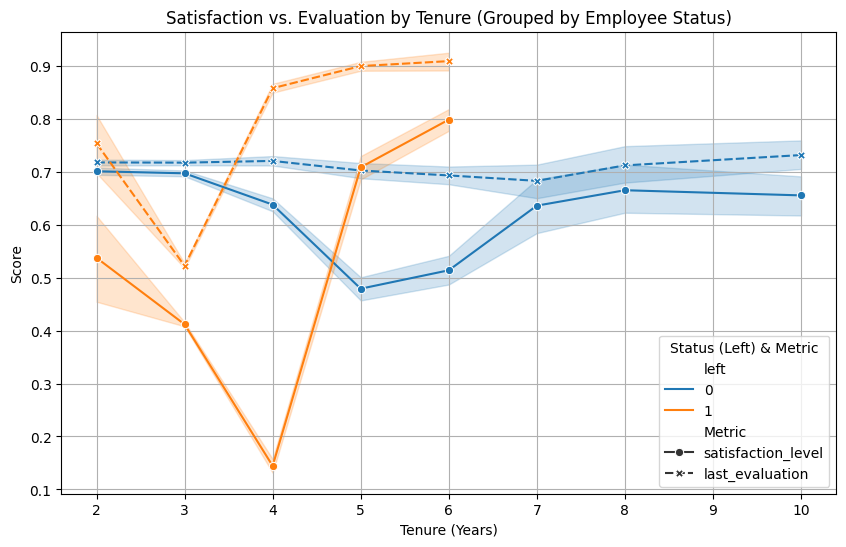

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


df_melted = df1.melt(id_vars=['tenure', 'left'], 
                    value_vars=['satisfaction_level', 'last_evaluation'],
                    var_name='Metric', 
                    value_name='Score')

# 2. Create the lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_melted, 
    x='tenure', 
    y='Score', 
    hue='left',      
    style='Metric', 
    markers=True
)

plt.title('Satisfaction vs. Evaluation by Tenure (Grouped by Employee Status)')
plt.xlabel('Tenure (Years)')
plt.ylabel('Score')
plt.legend(title='Status (Left) & Metric')
plt.grid(True)
plt.show()


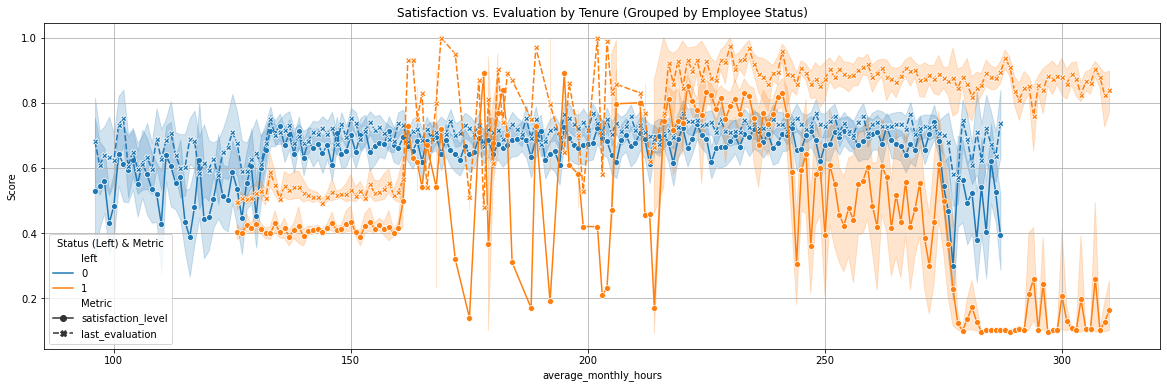

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


df_melted = df1.melt(id_vars=['average_monthly_hours', 'left'], 
                    value_vars=['satisfaction_level', 'last_evaluation'],
                    var_name='Metric', 
                    value_name='Score')

# 2. Create the lineplot
plt.figure(figsize=(20, 6))
sns.lineplot(
    data=df_melted, 
    x='average_monthly_hours', 
    y='Score', 
    hue='left',      
    style='Metric', 
    markers=True
)

plt.title('Satisfaction vs. Evaluation by Tenure (Grouped by Employee Status)')
plt.xlabel('average_monthly_hours')
plt.ylabel('Score')
plt.legend(title='Status (Left) & Metric')
plt.grid(True)
plt.show()


In [24]:

left_df = df1[df1['left'] == 1]
stayed_df = df1[df1['left'] == 0]
print("Median satisfation level of people who left the company", left_df['satisfaction_level'].median())
print("Median satisfation level of people who stayed in the company", stayed_df['satisfaction_level'].median())

print("Median last evaluation of people who left the company", left_df['last_evaluation'].median())
print("Median last evaluation of people who stayed in the company", stayed_df['last_evaluation'].median())

Median satisfation level of people who left the company 0.41
Median satisfation level of people who stayed in the company 0.69
Median last evaluation of people who left the company 0.79
Median last evaluation of people who stayed in the company 0.71


In [25]:
# Create a plot as needed
### YOUR CODE HERE ###
left_df['department'].value_counts(normalize = True)

department
sales          0.276243
technical      0.195881
support        0.156705
IT             0.079357
hr             0.056755
marketing      0.056253
product_mng    0.055249
accounting     0.054746
RandD          0.042692
management     0.026118
Name: proportion, dtype: float64

In [26]:
#Creating dataframe of people who left eh company, and where of the following department(sales, technical and support)
# as these 3 departments comprises of almost 64% of people who left the company
main_dept_left_df = left_df[(left_df['department'] == 'sales') | (left_df['department'] == 'technical') | (left_df['department'] == 'support')]

In [27]:
main_dept_left_df['tenure']. value_counts(normalize = True)

tenure
3    0.424920
5    0.250000
4    0.249201
6    0.055911
2    0.019968
Name: proportion, dtype: float64

In [28]:
main_dept_left_df['salary']. value_counts(normalize = True)

salary
low       0.597444
medium    0.380990
high      0.021565
Name: proportion, dtype: float64

In [29]:
df_4years_tenure = df1[df1['tenure'] <= 4]


In [30]:
df_4years_tenure.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
2,0.11,0.88,7,272,4,0,1,0,sales,medium
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low


In [31]:
df_4years_tenure['salary'].value_counts()

salary
low       4879
medium    4399
high       827
Name: count, dtype: int64

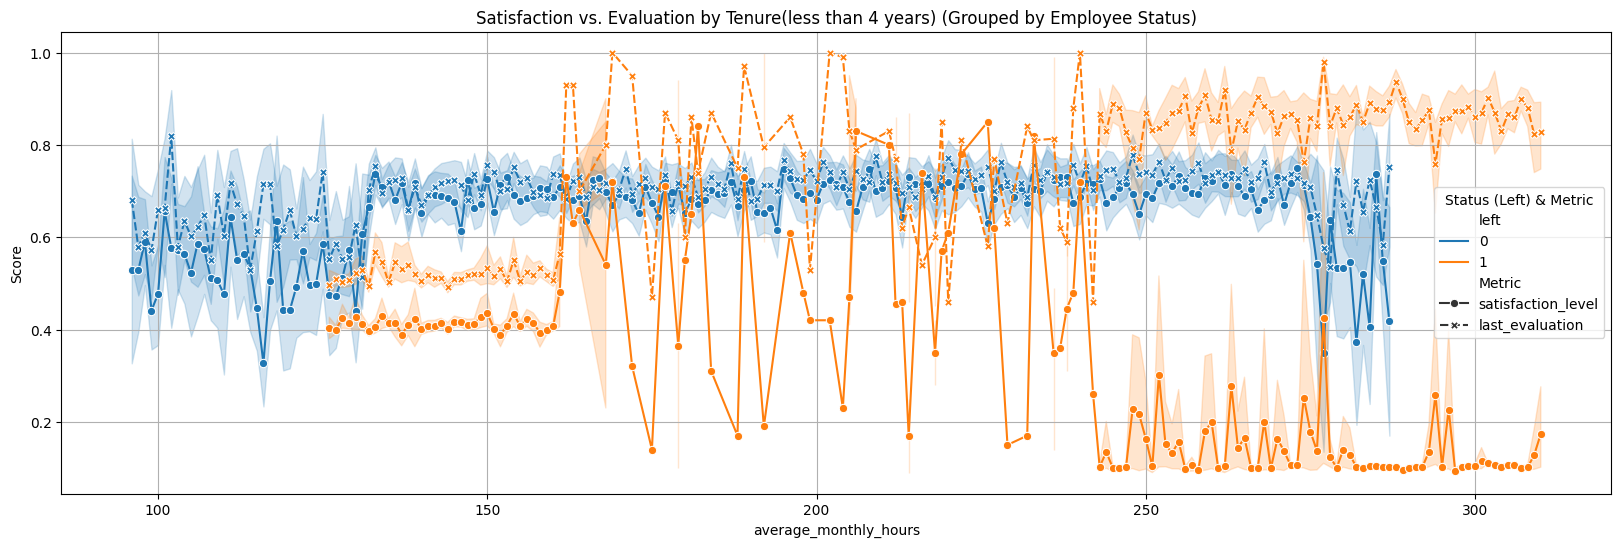

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


df_melted = df_4years_tenure.melt(id_vars=['average_monthly_hours', 'left'], 
                    value_vars=['satisfaction_level', 'last_evaluation'],
                    var_name='Metric', 
                    value_name='Score')

# 2. Create the lineplot
plt.figure(figsize=(20, 6))
sns.lineplot(
    data=df_melted, 
    x='average_monthly_hours', 
    y='Score', 
    hue='left',      
    style='Metric', 
    markers=True
)

plt.title('Satisfaction vs. Evaluation by Tenure(less than 4 years) (Grouped by Employee Status)')
plt.xlabel('average_monthly_hours')
plt.ylabel('Score')
plt.legend(title='Status (Left) & Metric')
plt.grid(True)
plt.show()


In [33]:
df_4years_tenure['department'].value_counts(normalize = True)

department
sales          0.268382
technical      0.189708
support        0.153488
IT             0.081247
RandD          0.057694
product_mng    0.057595
marketing      0.056012
accounting     0.052152
hr             0.050866
management     0.032855
Name: proportion, dtype: float64

In [34]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

[Double-click to enter your responses here.]

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

### Modeling

Add as many cells as you need to conduct the modeling process.

In [36]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 9.5 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/38.1 MB 23.2 MB/s eta 0:00:02
   ------------ --------------------------- 11.8/38.1 MB 28.4 MB/s eta 0:00:01
   -------------------- ------------------- 19.7/38.1 MB 31.0 MB/s eta 0:00:01
   ----------------------------- ---------- 27.8/38.1 MB 33.2 MB/s eta 0:00:01
   ----------------------------------- ---- 34.1/38.1 MB 32.8 MB/s eta 0:00:01
   ---------------------------------------  37.2/38.1 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 27.2 MB/s e


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [44]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

# Scikit-Learn tools
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Ignore some convergence warnings for cleaner output during GridSearch
import warnings
warnings.filterwarnings('ignore')

In [45]:
# 1. Load Data (Replace with your actual file path if needed)
# df = pd.read_csv('your_data.csv') 

# 2. Define Features and Target
X = df.drop('left', axis=1)
y = df['left']

# 3. Define Column Types
cat_cols = ['department', 'salary']
num_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 
            'average_monthly_hours', 'tenure', 'work_accident', 'promotion_last_5years']

# 4. Create Preprocessor Engine
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# 5. Split Data (Stratified ensures equal distribution of the target variable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# Define the base models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Define the hyperparameter grids for GridSearch
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__penalty': ['l2']
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 10, 20]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.1, 0.2]
    }
}

In [47]:
# Define Cross-Validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store the best trained pipelines and their evaluation metrics
best_models = {}
evaluation_results = []

print("Starting GridSearch and Cross-Validation Training...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Construct the pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Setup GridSearch
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv_strategy,
        scoring='roc_auc', # Optimizing for Area Under the Curve
        n_jobs=-1          # Use all available CPU cores
    )
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    
    # Store best model
    best_models[name] = grid_search.best_estimator_
    
    # Generate predictions using the best model
    y_pred = grid_search.best_estimator_.predict(X_test)
    y_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
    
    # Calculate Metrics
    evaluation_results.append({
        'Model': name,
        'Best Params': str(grid_search.best_params_),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

print("\nTraining Complete!")

Starting GridSearch and Cross-Validation Training...

Training Logistic Regression...
Training Decision Tree...
Training XGBoost...

Training Complete!


In [48]:
# Convert results dictionary to a clean pandas DataFrame
results_df = pd.DataFrame(evaluation_results)

# Display the comparison table, rounding numbers for readability
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
print("=== Model Evaluation Comparison ===")
display(results_df[display_cols].round(4))

# Identify the absolute best model based on ROC-AUC
best_model_name = results_df.sort_values(by='ROC-AUC', ascending=False).iloc[0]['Model']
print(f"\nBest Overall Model: {best_model_name}")

=== Model Evaluation Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8349,0.5062,0.2060,0.2929,0.8450
1,Decision Tree,0.9800,0.9534,0.9246,0.9388,0.9738
2,XGBoost,0.9833,0.9661,0.9322,0.9488,0.9842



Best Overall Model: XGBoost


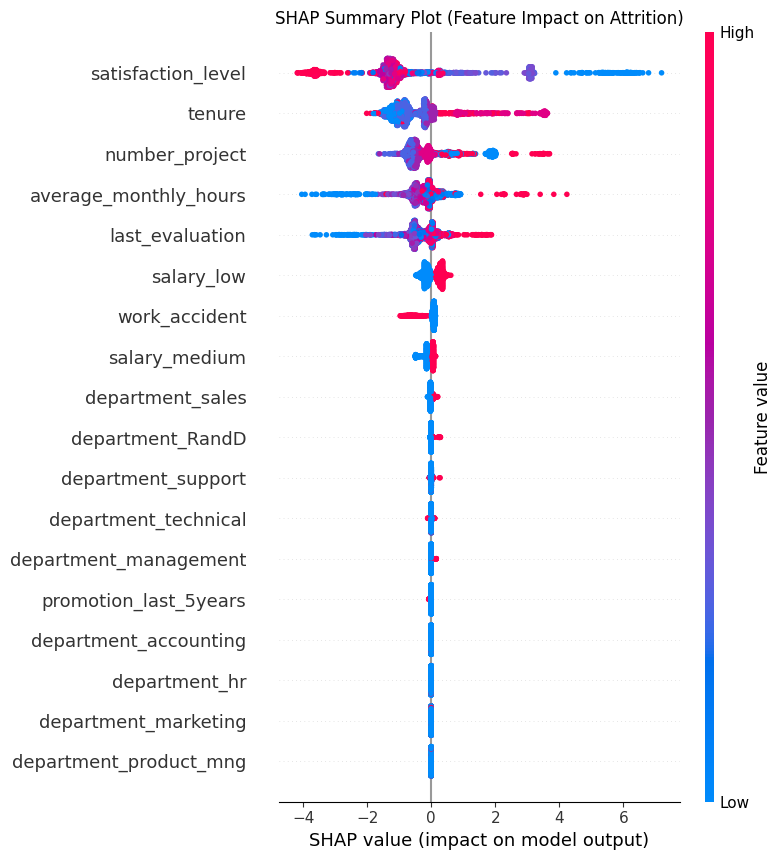

In [51]:

# We will use XGBoost here as it is standard for tabular data explainability.
best_xgb_pipeline = best_models['XGBoost']

# 1. Extract the preprocessed test data
X_test_transformed = best_xgb_pipeline.named_steps['preprocessor'].transform(X_test)

# 2. Extract feature names correctly from the ColumnTransformer
cat_features_out = best_xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features_out)

# 3. Create a DataFrame with the transformed data and column names
X_test_shap = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# 4. Extract the classifier itself from the pipeline
xgb_classifier = best_xgb_pipeline.named_steps['classifier']

# 5. Calculate SHAP values
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test_shap)

# 6. Plot the Summary
plt.title("SHAP Summary Plot (Feature Impact on Attrition)")
shap.summary_plot(shap_values, X_test_shap)

In [52]:
# Define the filename
filename = 'best_employee_attrition_model.pkl'

# Select the overall best pipeline
final_model = best_models[best_model_name]

# Save to disk
with open(filename, 'wb') as file:
    pickle.dump(final_model, file)

print(f"Successfully saved {best_model_name} pipeline to {filename}")

# --- Example of how to load it later ---
# with open('best_employee_attrition_model.pkl', 'rb') as file:
#     loaded_model = pickle.load(file)
# new_predictions = loaded_model.predict(new_employee_dataframe)

Successfully saved XGBoost pipeline to best_employee_attrition_model.pkl


In [53]:
print(grid_search.best_params_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}


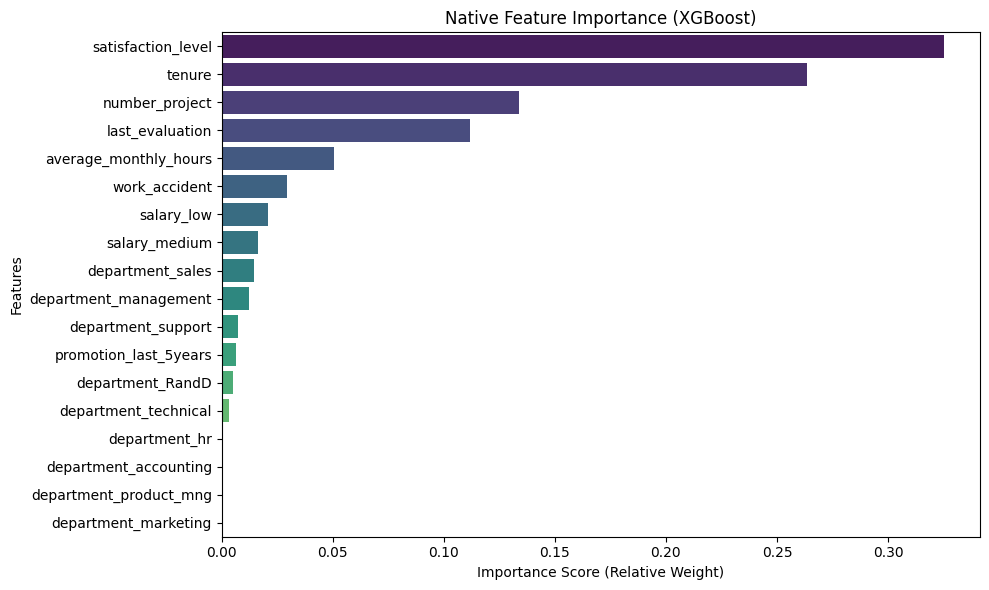


Top 5 Most Important Features:


,Feature,Importance
0,satisfaction_level,0.325167
4,tenure,0.263642
2,number_project,0.133887
1,last_evaluation,0.111957
3,average_monthly_hours,0.050358


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab the best model pipeline (assuming XGBoost or Decision Tree won)
# If you want to force it to look at XGBoost specifically:
model_pipeline = best_models['XGBoost']

# 2. Extract the classifier and the preprocessor from the pipeline
classifier = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

# 3. Retrieve the final feature names after One-Hot Encoding
cat_features_out = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features_out)

# 4. Extract the built-in feature importances
# (Note: Logistic Regression doesn't have .feature_importances_, it has .coef_)
importances = classifier.feature_importances_

# 5. Create a Pandas DataFrame to match feature names to their importance scores
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Sort the values from highest to lowest
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 6. Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Native Feature Importance (XGBoost)')
plt.xlabel('Importance Score (Relative Weight)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print the top 5 most important features as text
print("\nTop 5 Most Important Features:")
display(importance_df.head(5))

<Axes: title={'center': 'Top 10 Features'}>

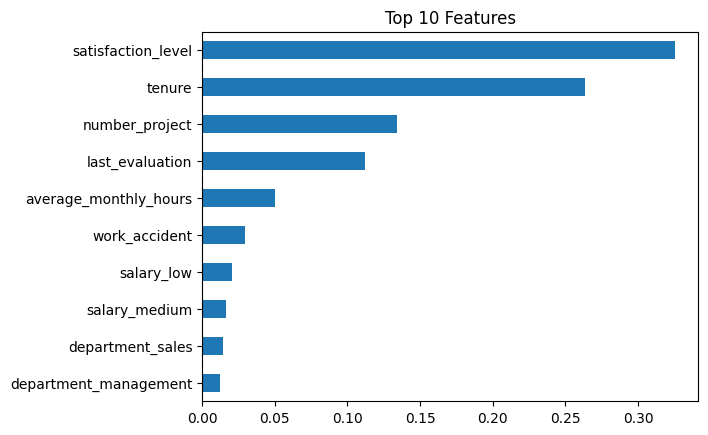

In [55]:
# Create a Pandas Series, grab the top 10, sort them, and plot a horizontal bar chart!
pd.Series(xgb_classifier.feature_importances_, index=all_feature_names).nlargest(10).sort_values().plot.barh(title="Top 10 Features")

In [64]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-Learn tools
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [65]:
# 1. Load Data (Assuming 'df' is your loaded dataframe)
# df = pd.read_csv('your_data.csv') 

X = df.drop('left', axis=1)
y = df['left']

cat_cols = ['department', 'salary']
num_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 
            'average_monthly_hours', 'tenure', 'work_accident', 'promotion_last_5years']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# --- THE SPLITS ---
# Split 1: Isolate the 20% Test Set (The final judge for BOTH methods)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split 2: Create the Holdout Sets (Split the remaining 80% into 60% Train / 20% Val)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

print("=== Data Distribution ===")
print(f"Cross-Validation Data (Train_Full): {len(X_train_full)} rows (80%)")
print(f"Holdout Train Data: {len(X_train)} rows (60%)")
print(f"Holdout Validation Data: {len(X_val)} rows (20%)")
print(f"Unseen Final Test Data: {len(X_test)} rows (20%)")

=== Data Distribution ===
Cross-Validation Data (Train_Full): 9592 rows (80%)
Holdout Train Data: 7194 rows (60%)
Holdout Validation Data: 2398 rows (20%)
Unseen Final Test Data: 2399 rows (20%)


In [66]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__penalty': ['l2']
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 10, 20]
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.1, 0.2]
    }
}

In [67]:
best_cv_models = {}
best_holdout_models = {}

print("Training models using both Validation strategies...\n")

for name, model in models.items():
    print(f"--- Processing {name} ---")
    
    # ---------------------------------------------------------
    # METHOD 1: 5-Fold Cross Validation (Using 80% Train_Full)
    # ---------------------------------------------------------
    cv_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid_search = GridSearchCV(
        estimator=cv_pipeline, param_grid=param_grids[name], 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
        scoring='roc_auc', n_jobs=-1
    )
    grid_search.fit(X_train_full, y_train_full)
    best_cv_models[name] = grid_search.best_estimator_
    print(f"  CV Best Params: {grid_search.best_params_}")

    # ---------------------------------------------------------
    # METHOD 2: Holdout Validation (Train on 60%, Evaluate on 20%)
    # ---------------------------------------------------------
    best_score = 0
    best_params = None
    best_holdout_model = None
    
    # Preprocess the holdout validation set once to speed up the loop
    X_train_prepped = preprocessor.fit_transform(X_train)
    X_val_prepped = preprocessor.transform(X_val)
    
    # Strip the 'classifier__' prefix for the custom loop
    raw_grid = {k.replace('classifier__', ''): v for k, v in param_grids[name].items()}
    
    # Test every parameter combination on the Validation Set
    for params in ParameterGrid(raw_grid):
        current_model = model.__class__(**params, **{'random_state': 42})
        if name == 'XGBoost':
            current_model.set_params(eval_metric='logloss', use_label_encoder=False)
        elif name == 'Random Forest':
            current_model.set_params(n_jobs=-1)
            
        current_model.fit(X_train_prepped, y_train)
        
        # Evaluate on the Validation Set
        val_probs = current_model.predict_proba(X_val_prepped)[:, 1]
        score = roc_auc_score(y_val, val_probs)
        
        if score > best_score:
            best_score = score
            best_params = params
            best_holdout_model = current_model

    # Reconstruct the winning pipeline for Holdout
    holdout_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                       ('classifier', best_holdout_model)])
    best_holdout_models[name] = holdout_pipeline
    print(f"  Holdout Best Params: {best_params}\n")

print("Training Complete!")

Training models using both Validation strategies...

--- Processing Logistic Regression ---
  CV Best Params: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}
  Holdout Best Params: {'C': 0.1, 'penalty': 'l2'}

--- Processing Decision Tree ---
  CV Best Params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 20}
  Holdout Best Params: {'max_depth': 7, 'min_samples_split': 20}

--- Processing Random Forest ---
  CV Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
  Holdout Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

--- Processing XGBoost ---
  CV Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
  Holdout Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Training Complete!


In [68]:
results = []

def evaluate_model(models_dict, method_name):
    for name, pipeline in models_dict.items():
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        results.append({
            'Model': name,
            'Validation Method': method_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba)
        })

# Evaluate both strategies on the completely unseen Test Set
evaluate_model(best_cv_models, 'Cross-Validation (5-Fold)')
evaluate_model(best_holdout_models, 'Holdout (60/20)')

# Create DataFrame, sort by ROC-AUC to find the absolute winner
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("=== Final Test Set Performance Comparison ===")
display(results_df.round(4))

# Identify the overall best model and method
best_row = results_df.iloc[0]
best_overall_name = best_row['Model']
best_overall_method = best_row['Validation Method']

print(f"\nOverall Winner: {best_overall_name} trained via {best_overall_method}")

# Store the absolute best pipeline for Explainability and Saving
if 'Cross' in best_overall_method:
    final_best_pipeline = best_cv_models[best_overall_name]
else:
    final_best_pipeline = best_holdout_models[best_overall_name]

=== Final Test Set Performance Comparison ===


,Model,Validation Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,Cross-Validation (5-Fold),0.9833,0.9661,0.9322,0.9488,0.9842
1,XGBoost,Holdout (60/20),0.9846,0.9738,0.9322,0.9525,0.9839
2,Random Forest,Cross-Validation (5-Fold),0.9842,0.9839,0.9196,0.9506,0.9794
3,Random Forest,Holdout (60/20),0.9862,0.9893,0.9271,0.9572,0.9773
4,Decision Tree,Holdout (60/20),0.9837,0.9711,0.9296,0.9499,0.9742
5,Decision Tree,Cross-Validation (5-Fold),0.9800,0.9534,0.9246,0.9388,0.9738
6,Logistic Regression,Cross-Validation (5-Fold),0.8349,0.5062,0.2060,0.2929,0.8450
7,Logistic Regression,Holdout (60/20),0.8366,0.5190,0.2060,0.2950,0.8431



Overall Winner: XGBoost trained via Cross-Validation (5-Fold)


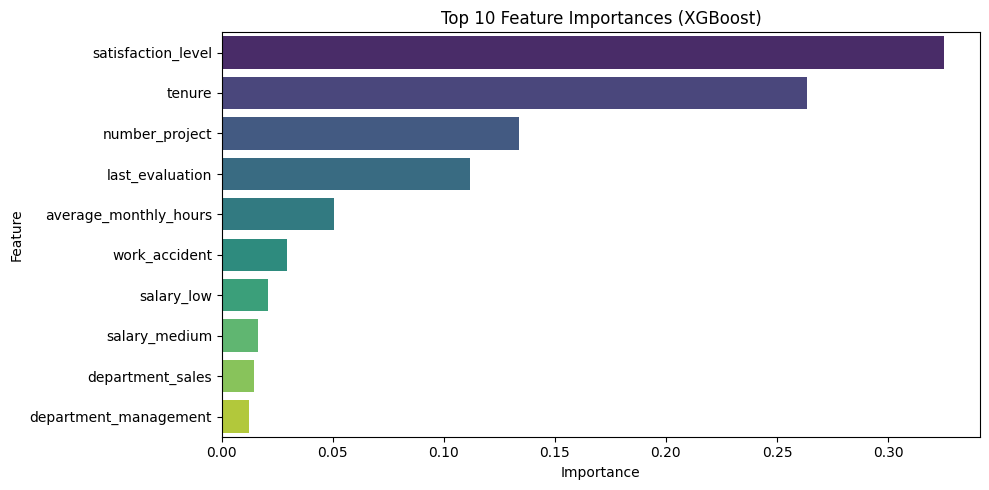

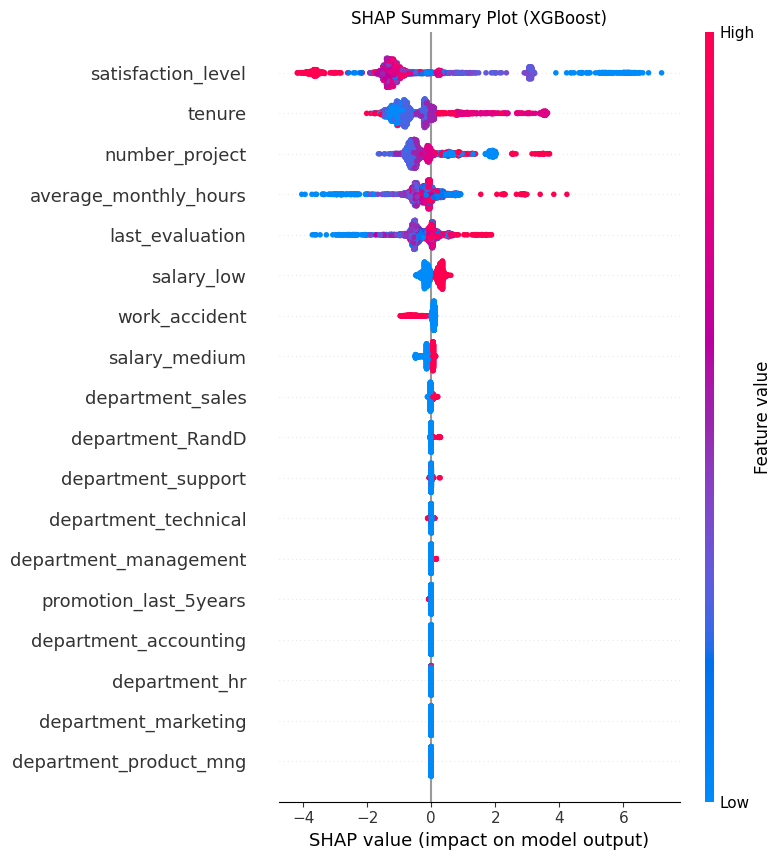

In [69]:
# 1. Extract necessary components from the winning pipeline
classifier = final_best_pipeline.named_steps['classifier']
prep = final_best_pipeline.named_steps['preprocessor']

# 2. Get feature names
cat_features_out = prep.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features_out)

# --- NATIVE FEATURE IMPORTANCE ---
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
    plt.title(f'Top 10 Feature Importances ({best_overall_name})')
    plt.tight_layout()
    plt.show()

# --- SHAP EXPLAINABILITY ---
# Prepare the test data for SHAP
X_test_transformed = prep.transform(X_test)
X_test_shap = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# We use TreeExplainer for Tree models. (If Logistic Regression won, this step is skipped to avoid errors)
if best_overall_name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(classifier)
    
    # Random Forest returns SHAP values for both classes (0 and 1). We only want class 1 (attrition).
    if best_overall_name == 'Random Forest':
        shap_values = explainer.shap_values(X_test_shap)[1] 
    else:
        shap_values = explainer.shap_values(X_test_shap)
        
    plt.title(f"SHAP Summary Plot ({best_overall_name})")
    shap.summary_plot(shap_values, X_test_shap)
else:
    print("\nSHAP visual skipped: The winning model is Linear, which requires a different SHAP explainer.")

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.